In [53]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt 

In [54]:
'''

EACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS

1) ACQUIRE THE DATA 

2) DEFINE THE STRATEGY 

3) TEST THE STRATEGY


'''

'\n\nEACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS\n\n1) ACQUIRE THE DATA \n\n2) DEFINE THE STRATEGY \n\n3) TEST THE STRATEGY\n\n\n'

In [55]:
'''
EXPONENTIAL MOVING AVERAGE FORMULA: (Current Price - Previous EMA) * Multiplier + Previous EMA
'''

'\nEXPONENTIAL MOVING AVERAGE FORMULA: (Current Price - Previous EMA) * Multiplier + Previous EMA\n'

In [56]:
TICKER = "SPY"
LOOKBACK = 500
WINDOW = 8
MULTIPLIER = 2 / (WINDOW + 1)

In [57]:
def load_dataset(symbol):
    df = yf.download(TICKER, period="max")
    df.columns = df.columns.get_level_values(0)
    return pd.DataFrame(df)

In [58]:
df = load_dataset(TICKER)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
1993-01-29,24.175383,24.192577,24.072216,24.192577,1003200
1993-02-01,24.347313,24.347313,24.192563,24.192563,480500
1993-02-02,24.398911,24.416105,24.278549,24.330133,201300
1993-02-03,24.656822,24.674017,24.416100,24.433295,529400
1993-02-04,24.760000,24.811584,24.467695,24.742806,531500
...,...,...,...,...,...
2026-05-08,737.619995,738.080017,734.570007,734.929993,47227100
2026-05-11,739.299988,740.789978,736.450012,736.450012,44024000
2026-05-12,738.179993,738.840027,731.830017,736.890015,54185300


In [59]:
# calculate the ema using the sma
def exponential_moving_average(df):
    try:
        df["SMA"] = df["Close"].rolling(window=WINDOW).mean()
        df["EMA"] = df["SMA"].ewm(span=WINDOW, adjust=False).mean()
    except Exception as e:
        print(f"error: {e}")
    return df.dropna()

In [60]:
df = exponential_moving_average(df)
df

Price,Close,High,Low,Open,Volume,SMA,EMA
Date,,,,,,,
1993-02-09,24.570856,24.656828,24.519273,24.656828,122100,24.549363,24.549363
1993-02-10,24.605242,24.622436,24.502075,24.570853,379600,24.603095,24.561303
1993-02-11,24.725615,24.828781,24.639642,24.639642,19500,24.650383,24.581099
1993-02-12,24.536461,24.691211,24.536461,24.691211,42500,24.667577,24.600316
1993-02-16,23.917473,24.467695,23.883084,24.467695,374800,24.575158,24.594726
...,...,...,...,...,...,...,...
2026-05-08,737.619995,738.080017,734.570007,734.929993,47227100,724.462509,716.603046
2026-05-11,739.299988,740.789978,736.450012,736.450012,44024000,727.927505,719.119593
2026-05-12,738.179993,738.840027,731.830017,736.890015,54185300,730.367508,721.619129


In [ ]:
# plot the asset against the exponential moving average
def plot_exponential_moving_average(df):
    df = df.iloc[-LOOKBACK:, :]
    plt.plot(df["Close"], label="SPY Closing Price")
    plt.plot(df["EMA"], label="Exponential Moving Average")
    plt.title("SPY Close Price vs EMA")
    plt.xlabel("Date")
    plt.ylabel("Closing Price $")
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

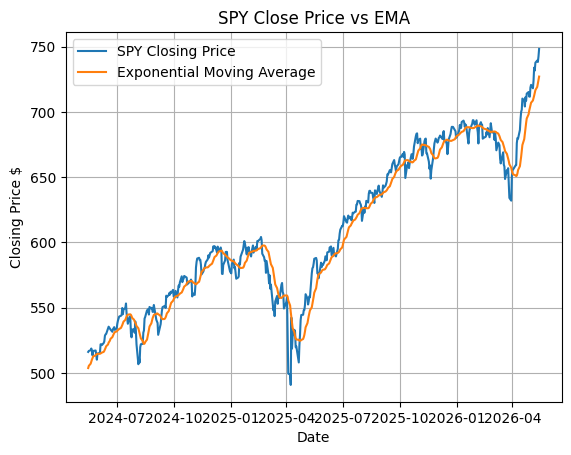

In [62]:
plot_exponential_moving_average(df)

In [ ]:
'''
DEFINE STRATEGY:
'''